# Transformer: uniform sampling (Alg. 1) vs UCB (Alg. 3)

Character-level transformer from `start_model.ipynb`. The input is a 32-character context from the
validation text; the domain perturbs the first $k$ coordinates of the last token's embedding by at most $r$.
The objective is $\|\nabla_z\, c^\top f(x_0 + z)\|_1$ for the logits $f$ at the last position,
$c = e_0 - e_1$.

In [1]:
import sys
import json
from pathlib import Path
sys.path.append('..')

import numpy as np
import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt

from hyperbox import Hyperbox
from other_methods import StochasticApproximation, StochasticApproximationUCBDynamic

In [2]:
block_size = 32
n_embd     = 64
n_head     = 4
n_layer    = 4
dropout    = 0.0
device     = 'cpu'

with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()
chars      = sorted(list(set(text)))
vocab_size = len(chars)
stoi       = {ch: i for i, ch in enumerate(chars)}

class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key   = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x); q = self.query(x)
        wei = q @ k.transpose(-2, -1) * C ** -0.5
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        v = self.value(x)
        return wei @ v

class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj  = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        return self.dropout(self.proj(out))

class FeedFoward(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )
    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa   = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedFoward(n_embd)
        self.ln1  = nn.LayerNorm(n_embd)
        self.ln2  = nn.LayerNorm(n_embd)
    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

class BigramLanguageModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table    = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.ln_f   = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)
    def forward(self, x):
        x = self.blocks(x)
        x = self.ln_f(x)
        return self.lm_head(x)

model = BigramLanguageModel().to(device)
model.load_state_dict(torch.load('model_weights.pth', map_location=device))
model.eval()
for p in model.parameters():
    p.requires_grad_(False)
print(sum(p.numel() for p in model.parameters()) / 1e6, 'M parameters')

0.209729 M parameters


In [3]:
K, R = 4, 1.0
CONTEXT = text[int(0.9 * len(text)):][:block_size]
C_VECTOR = torch.zeros(vocab_size)
C_VECTOR[0], C_VECTOR[1] = 1.0, -1.0
PRIMAL_NORM = 'linf'

BUDGET = 50000
SEEDS = range(5)
TUNE_SEEDS = range(100, 105)
TUNE_GRID = [(c, p) for c in (1.0, 5.0, 15.0) for p in (2, 1.5)]

OUT_DIR = Path('transformer_convergence_out')
OUT_DIR.mkdir(exist_ok=True)
TAG = f'k{K}_r{R}_budget{BUDGET}_seeds{len(SEEDS)}'
COLORS = {'uniform (Alg. 1)': '#2a78d6', 'UCB (Alg. 3)': '#eb6834'}


class LastToken(nn.Module):
    """ z (k,) -> logits (1, vocab) at the last position of x0 with z added to the last token's first k coordinates. """
    def __init__(self, net, x0, k):
        super().__init__()
        self.net, self.k = net, k
        self.register_buffer('x0', x0)
    def forward(self, z):
        x = self.x0.clone()
        x[-1, :self.k] = x[-1, :self.k] + z.reshape(-1)
        return self.net(x.unsqueeze(0))[:, -1]


tokens = torch.tensor([stoi[ch] for ch in CONTEXT])
x0 = model.token_embedding_table(tokens) + model.position_embedding_table(torch.arange(len(tokens)))
net = LastToken(model, x0.detach(), K)
DOMAIN = Hyperbox.build_custom_hypercube(K, 0.0, R)



def uniform():
    return StochasticApproximation(net, C_VECTOR, DOMAIN, primal_norm=PRIMAL_NORM)

def ucb(c, p):
    return StochasticApproximationUCBDynamic(net, C_VECTOR, DOMAIN, c=c, partition_step=p, primal_norm=PRIMAL_NORM)

print(repr(CONTEXT))

'?\n\nGREMIO:\nGood morrow, neighbou'


In [4]:
def final_value(make, seed):
    torch.manual_seed(seed); np.random.seed(seed)
    return float(make().compute(max_iter=BUDGET))


tuning = {}
for c, p in TUNE_GRID:
    tuning[f'c={c}, p={p}'] = np.mean([final_value(lambda: ucb(c, p), s) for s in TUNE_SEEDS])
    print(f'c={c:>4}, p={p}: {tuning[f"c={c}, p={p}"]:.4f}')
UCB_C, UCB_PARTITION = max(TUNE_GRID, key=lambda cp: tuning[f'c={cp[0]}, p={cp[1]}'])
print(f'selected c={UCB_C}, p={UCB_PARTITION}')

c= 1.0, p=2: 0.5115
c= 1.0, p=1.5: 0.5067
c= 5.0, p=2: 0.5193
c= 5.0, p=1.5: 0.5238
c=15.0, p=2: 0.5262
c=15.0, p=1.5: 0.5273
selected c=15.0, p=1.5


In [5]:
methods = {'uniform (Alg. 1)': uniform, 'UCB (Alg. 3)': lambda: ucb(UCB_C, UCB_PARTITION)}

runs = {name: [] for name in methods}
for name, make in methods.items():
    for seed in SEEDS:
        torch.manual_seed(seed); np.random.seed(seed)
        solver = make()
        solver.compute(max_iter=BUDGET)
        runs[name].append((np.array(solver.history), solver.compute_time))
        print(f'{name:>17}  seed {seed}: {float(solver.value):.4f}  ({solver.compute_time:.1f} s)')

with open(OUT_DIR / f'{TAG}.json', 'w') as f:
    json.dump({'config': dict(k=K, r=R, context=CONTEXT, budget=BUDGET, seeds=list(SEEDS), ucb_c=UCB_C,
                              ucb_partition=UCB_PARTITION, c_vector='e0-e1', primal_norm=PRIMAL_NORM,
                              tune_seeds=list(TUNE_SEEDS), tuning=tuning),
               'runs': {name: [dict(history=h.tolist(), seconds=t) for h, t in r] for name, r in runs.items()}},
              f)

 uniform (Alg. 1)  seed 0: 0.5275  (124.7 s)
 uniform (Alg. 1)  seed 1: 0.5269  (119.9 s)
 uniform (Alg. 1)  seed 2: 0.5263  (119.8 s)
 uniform (Alg. 1)  seed 3: 0.5259  (119.6 s)
 uniform (Alg. 1)  seed 4: 0.5125  (120.1 s)
     UCB (Alg. 3)  seed 0: 0.5275  (122.4 s)
     UCB (Alg. 3)  seed 1: 0.5273  (121.8 s)
     UCB (Alg. 3)  seed 2: 0.5274  (121.7 s)
     UCB (Alg. 3)  seed 3: 0.5270  (122.9 s)
     UCB (Alg. 3)  seed 4: 0.5273  (122.1 s)


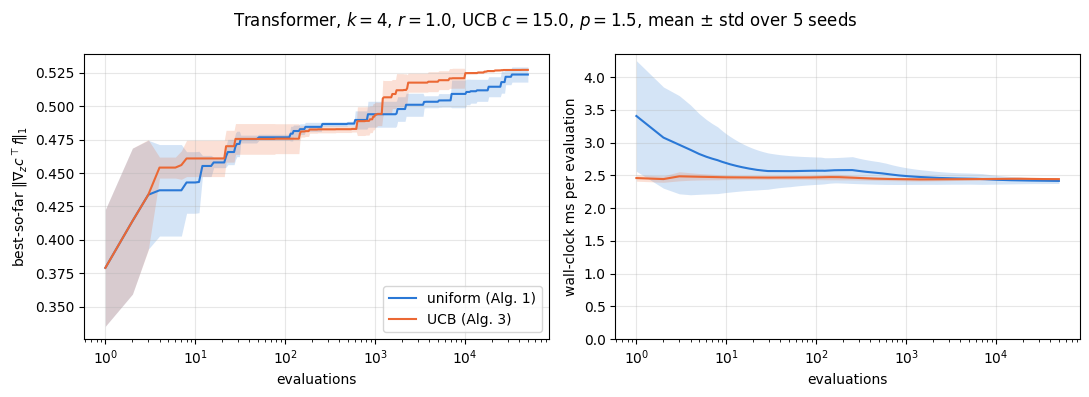

In [6]:
with open(OUT_DIR / f'{TAG}.json') as f:
    saved = json.load(f)
cfg = saved['config']
runs = {name: [(np.array(r['history']), r['seconds']) for r in rs] for name, rs in saved['runs'].items()}


def best_so_far(hist, grid):
    idx = np.searchsorted(hist[:, 0], grid, side='right') - 1
    return hist[idx, 2]


def ms_per_eval(hist, seconds, grid):
    n, t = np.append(hist[:, 0], cfg['budget']), np.append(hist[:, 1], seconds)
    return 1e3 * np.interp(grid, n, t) / grid


grid = np.unique(np.geomspace(1, cfg['budget'], 400).astype(int))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, r in runs.items():
    for ax, curves in [(axes[0], [best_so_far(h, grid) for h, _ in r]),
                       (axes[1], [ms_per_eval(h, t, grid) for h, t in r])]:
        m, s = np.mean(curves, 0), np.std(curves, 0)
        ax.plot(grid, m, color=COLORS[name], label=name)
        ax.fill_between(grid, m - s, m + s, color=COLORS[name], alpha=0.2, lw=0)
for ax in axes:
    ax.set_xscale('log'); ax.set_xlabel('evaluations'); ax.grid(alpha=0.3)
axes[0].set_ylabel(r'best-so-far $\|\nabla_z c^\top f\|_1$')
axes[1].set_ylabel('wall-clock ms per evaluation')
axes[1].set_ylim(bottom=0)
axes[0].legend(loc='lower right')
fig.suptitle(f"Transformer, $k={cfg['k']}$, $r={cfg['r']}$, UCB $c={cfg['ucb_c']}$, $p={cfg['ucb_partition']}$, "
             f"mean $\\pm$ std over {len(cfg['seeds'])} seeds")
plt.tight_layout()
for ext in ('png', 'pdf'):
    fig.savefig(OUT_DIR / f'{TAG}.{ext}', dpi=200, bbox_inches='tight')
plt.show()

In [7]:
best = max(h[-1, 2] for r in runs.values() for h, _ in r)
seconds = {name: np.mean([t for _, t in r]) for name, r in runs.items()}
print(f'best value over all runs: {best:.4f}\n')
print(f"{'method':>17}  {'final':>16}  {'evals to 95%':>14}  {'evals to 99%':>14}  {'seconds':>8}")
for name, r in runs.items():
    finals = np.array([h[-1, 2] for h, _ in r])
    def reach(frac):
        hits = [h[np.argmax(h[:, 2] >= frac * best), 0] if (h[:, 2] >= frac * best).any() else np.nan for h, _ in r]
        n_hit = np.isfinite(hits).sum()
        return f'{np.nanmedian(hits):.0f} ({n_hit}/{len(r)})' if n_hit else f'- (0/{len(r)})'
    print(f'{name:>17}  {finals.mean():.4f} ± {finals.std():.4f}  {reach(0.95):>14}  {reach(0.99):>14}  {seconds[name]:>8.1f}')
print(f"\nUCB time overhead: {100 * (seconds['UCB (Alg. 3)'] / seconds['uniform (Alg. 1)'] - 1):+.1f}%")
print('reach columns: median over the seeds that reached the level (seeds reached / total)')

best value over all runs: 0.5275

           method             final    evals to 95%    evals to 99%   seconds
 uniform (Alg. 1)  0.5238 ± 0.0057      1739 (5/5)     26457 (4/5)     120.8
     UCB (Alg. 3)  0.5273 ± 0.0002      1209 (5/5)      3906 (5/5)     122.2

UCB time overhead: +1.1%
reach columns: median over the seeds that reached the level (seeds reached / total)


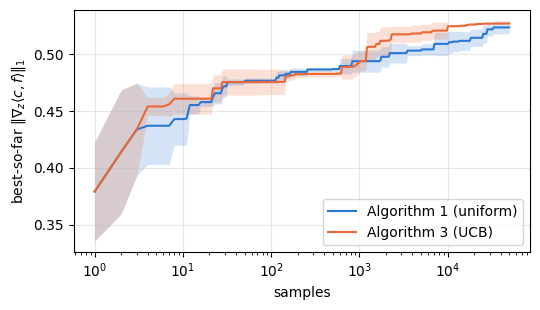

In [9]:
fig, ax = plt.subplots(figsize=(5.5, 3.2))
labels = {'uniform (Alg. 1)': 'Algorithm 1 (uniform)', 'UCB (Alg. 3)': 'Algorithm 3 (UCB)'}
for name, r in runs.items():
  curves = np.stack([best_so_far(h, grid) for h, _ in r])
  m, s = curves.mean(0), curves.std(0)
  ax.plot(grid, m, color=COLORS[name], label=labels[name])
  ax.fill_between(grid, m - s, m + s, color=COLORS[name], alpha=0.2, lw=0)
ax.set_xscale('log'); ax.grid(alpha=0.3)
ax.set_xlabel('samples')
ax.set_ylabel(r'best-so-far $\|\nabla_z \langle c, f \rangle\|_1$')
ax.legend(loc='lower right')
plt.tight_layout()
for ext in ('png', 'pdf'):
  fig.savefig(OUT_DIR / f'{TAG}_paper.{ext}', dpi=200, bbox_inches='tight')
plt.show()